# Week 1 - Data Wrangling & Exploratory Data Analysis
## Online Retail II Dataset

**Focus:** Understanding the dataset, identifying data quality issues, performing EDA, and making justified design decisions for future modelling.

**Key principle:** This week is about *thinking clearly about data*, not building models. Every decision must be reasoned and justified.

## Task 1 - Load and Inspect the Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

In [2]:
# Loading the Online Retail II dataset
df = pd.read_csv('online_retail.csv', encoding='latin1')

# Displaying the first few rows
df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,01/12/2009 07:45,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,01/12/2009 07:45,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,01/12/2009 07:45,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,01/12/2009 07:45,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,01/12/2009 07:45,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,01/12/2009 07:45,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,01/12/2009 07:45,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,01/12/2009 07:45,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,01/12/2009 07:46,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,01/12/2009 07:46,3.75,13085.0,United Kingdom


In [3]:
# Displaying Number of rows and columns
print(f"Number of rows:    {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")

Number of rows:    525,461
Number of columns: 8


In [4]:
# Checking Column names and data types
print("Column Names and Data Types:")
for col in df.columns:
    print(f"  {col:<15} -> {df[col].dtype}")

Column Names and Data Types:
  Invoice         -> str
  StockCode       -> str
  Description     -> str
  Quantity        -> int64
  InvoiceDate     -> str
  Price           -> float64
  Customer ID     -> float64
  Country         -> str


In [5]:
# Basic info summary
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      525461 non-null  str    
 1   StockCode    525461 non-null  str    
 2   Description  522533 non-null  str    
 3   Quantity     525461 non-null  int64  
 4   InvoiceDate  525461 non-null  str    
 5   Price        525461 non-null  float64
 6   Customer ID  417534 non-null  float64
 7   Country      525461 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 32.1 MB


In [6]:
# Quick statistical summary for numeric columns
df.describe()

,Quantity,Price,Customer ID
count,525461.000000,525461.000000,417534.000000
mean,10.337667,4.688834,15360.645478
std,107.424110,146.126914,1680.811316
min,-9600.000000,-53594.360000,12346.000000
25%,1.000000,1.250000,13983.000000
50%,3.000000,2.100000,15311.000000
75%,10.000000,4.210000,16799.000000
max,19152.000000,25111.090000,18287.000000


### What does a single row represent?

A single row in this dataset **represents a single invoice line item**, i.e., **it represents one product** (`StockCode`) **that was purchased in a quantity (`Quantity`) at a price (`Price`) on a date (`InvoiceDate`) for a customer (`Customer ID`) who had it shipped to a country (`Country`).

**Why do multiple rows share the same Invoice and Customer ID?**

- In general, **the same invoice will be represented by multiple rows**: In most cases, a customer will buy several products as part of one transaction (i.e., "basket") and therefore there will be a separate row for each product in that basket with the same invoice number; this means each invoice is a **group of rows**, not a single row.
- In addition, **customers can be found in multiple rows**: A customer may make multiple purchases in different periods. Each purchase will result in a new invoice and each invoice may contain multiple line items. Consequently, a customer can be seen in multiple rows spread out over multiple invoices and dates.

Finally, this data format indicates **rows are not independent records** rows are nested under invoices, and those are nested under customers.

## Task 2 - Define the Unit of Analysis

In [7]:
# examining the nesting structure to understand the units
print("Unique values at each level:")
print(f"Invoice line items (rows):  {len(df):,}")
print(f"Unique Invoices:            {df['Invoice'].nunique():,}")
print(f"Unique Customers:           {df['Customer ID'].nunique():,}")
print(f"Unique Products:            {df['StockCode'].nunique():,}")
print(f"Unique Countries:           {df['Country'].nunique()}")

Unique values at each level:
Invoice line items (rows):  525,461
Unique Invoices:            28,816
Unique Customers:           4,383
Unique Products:            4,632
Unique Countries:           40


In [8]:
# Average items per invoice
items_per_invoice = df.groupby('Invoice').size()
print("Items per invoice (line items):")
print(items_per_invoice.describe().round(2))

Items per invoice (line items):
count    28816.00
mean        18.24
std         34.87
min          1.00
25%          1.00
50%          8.00
75%         22.00
max        675.00
dtype: float64


In [9]:
# Invoices per customer
invoices_per_cust = df.dropna(subset=['Customer ID']).groupby('Customer ID')['Invoice'].nunique()
print("Invoices per customer:")
print(invoices_per_cust.describe().round(2))

Invoices per customer:
count    4383.00
mean        5.38
std        10.05
min         1.00
25%         1.00
50%         3.00
75%         6.00
max       270.00
Name: Invoice, dtype: float64


### Comparison of Units of Analysis

#### 1. Invoice Line Item (Row Level)
- **Information gained:** Most detailed level — every product, quantity and price per transaction is available. Ideal for product-based analysis.
- **Information lost:** The rows are dependent on each other. If they are treated as independent, the sample size is inflated and the statistical measures will be distorted. There is no customer or basket context either.

#### 2. Invoice / Basket Level
- **Information gained:** Every invoice is one shopping occasion. So we can calculate basket based variables (basket total, number of items, number of different products) and also remove the within basket dependency by aggregating all rows in a basket.
- **Information lost:** The product level details (which individual items were purchased) are lost. Multiple invoices from the same customer will still not be independent.

#### 3. Customer Level (Aggregated Across All Invoices)
- **Information gained:** Each row is an individual customer so these are independent observations. We can now create a wide variety of behavioral variables: Total spend, frequency, recency, average basket size, number of returns, etc. This is typically the most logical unit to use when doing customer centric work such as churn prediction or segmentation.
- **Information lost:** All temporal information is removed. Therefore we do not know the order or timing of the purchases. Unless you design some feature that captures this, customers who have only 1 purchase and customers who have made 100 purchases are treated identically.

#### 4. Customer Over a Time Window (e.g. Monthly)
- **Information gained:** The temporal nature of customer behavior is preserved we can observe the evolution of customer behavior through time. This is ideal for both time series analysis and panel type analyses.
- **Information lost:** The complexity has increased greatly there are issues around time boundaries that need to be addressed and there will likely be customers with missing or sparse time periods, creating irregular panel data.

### Decision: Customer Level

**I choose the customer as my unit of analysis for Week 2 onward.**

**Justification:**
1. **Independence**: Since we're using customer level data to create our observations, we have the ability to treat each observation as an independent piece of information; which is something that many machine learning algorithms require.
2. **Ability to generate new features**: The transactional history of each customer allows us to develop new variables related to how they behave in terms of total spend, frequency, recency, average basket value, return rate, etc., and product diversity.
3. **Naturally suited for prediction questions**: Questions about whether a customer will be returning or if a customer has the potential to be a high-value customer are examples of natural prediction questions that can be answered using the customer level data and have clear answers based on customer behavior.
4. **Reasonable amount of data**: There are approximately 4,383 unique customers in the data set, which is small enough to allow us to use tree-based modeling techniques.

While we lose some temporal aspects by treating customers as static, at least initially when developing a model that uses tree-based methods, this is acceptable because it's still possible to interpret the results.

## Task 3 - Data Quality and Validity Audit

In [10]:
# Missing Customer ID
missing_cid = df['Customer ID'].isnull().sum()
total = len(df)
print(f"Missing Customer ID")
print(f"Missing: {missing_cid:,} rows ({missing_cid/total*100:.1f}%)")
print(f"Present: {total - missing_cid:,} rows")

Missing Customer ID
Missing: 107,927 rows (20.5%)
Present: 417,534 rows


In [11]:
# What do missing-CustomerID rows look like?
print("Sample rows with missing Customer ID:")
df[df['Customer ID'].isnull()].head(10)

Sample rows with missing Customer ID:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,01/12/2009 10:52,0.00,NaN,United Kingdom
283,489463,71477,short,-240,01/12/2009 10:52,0.00,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,01/12/2009 10:53,0.00,NaN,United Kingdom
470,489521,21646,NaN,-50,01/12/2009 11:44,0.00,NaN,United Kingdom
577,489525,85226C,BLUE PULL BACK RACING CAR,1,01/12/2009 11:49,0.55,NaN,United Kingdom
578,489525,85227,SET/6 3D KIT CARDS FOR KIDS,1,01/12/2009 11:49,0.85,NaN,United Kingdom
1055,489548,22271,FELTCRAFT DOLL ROSIE,1,01/12/2009 12:32,2.95,NaN,United Kingdom
1056,489548,22254,FELT TOADSTOOL LARGE,12,01/12/2009 12:32,1.25,NaN,United Kingdom
1057,489548,22273,FELTCRAFT DOLL MOLLY,3,01/12/2009 12:32,2.95,NaN,United Kingdom
1058,489548,22195,LARGE HEART MEASURING SPOONS,1,01/12/2009 12:32,1.65,NaN,United Kingdom


### Missing Customer ID

**What this means**: I have 107,927 transactions (approximately 20.5%) that do not have a Customer ID. As such, these can't be tied to a customer.

**Why does it matter?** As I've defined our unit of analysis as the "Customer", any row(s) with missing values in the Customer ID will not be usable. We can't create customer profiles by aggregating those rows, nor will they be useful in making customer-specific predictions.

**Our decision**: **I should remove rows where Customer ID is missing**, as these rows will never contribute to our customer-level analyses. If we were to keep these rows, we'd essentially have two options: either perform some sort of imputation (for which there's no justification for identifiers), or we'll skew/alter the overall aggregated statistics.

In [12]:
# Cancelled invoices and negative quantities
cancelled = df[df['Invoice'].astype(str).str.startswith('C')]
print(f"Cancelled Invoices / Returns")
print(f"Rows starting with 'C': {len(cancelled):,}")
print(f"Negative quantities:     {(df['Quantity'] < 0).sum():,}")
print(f"Zero quantities:         {(df['Quantity'] == 0).sum():,}")
print()
print("Sample cancelled invoice rows:")
cancelled.head(8)

Cancelled Invoices / Returns
Rows starting with 'C': 10,206
Negative quantities:     12,326
Zero quantities:         0

Sample cancelled invoice rows:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,01/12/2009 10:33,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,01/12/2009 10:33,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,01/12/2009 10:33,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,01/12/2009 10:33,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,01/12/2009 10:33,2.95,16321.0,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,01/12/2009 10:33,1.25,16321.0,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,01/12/2009 10:33,1.25,16321.0,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,01/12/2009 10:33,0.85,16321.0,Australia


### Cancelled Invoices and Negative Quantities

**Description:** 
10,206 rows contain invoices that begin with 'C,' which indicates cancellations. In addition, there are 12,326 rows with negative quantity values; these indicate returns or reversals of a transaction, and do not reflect a purchase.

**Why this is important:**
If we were to count returns as typical purchases, we could increase our activity metric for customers by artificially increasing their transactions and would distort our ability to measure our revenue accurately. However, a customer's returns can provide information a customer who continually returns products has different behavior than one who does not return product.

**Recommendation:**
**Separate Returns from Purchases.** I will identify cancellation rows, and then eliminate them from any aggregating purchase metrics; however, I will utilise those same rows to create a "return rate" variable at the customer level. The return rates variable preserves the valuable information contained in the return data while eliminating them from being included in the purchase metrics.

In [13]:
# Extreme prices and quantities
print("Extreme Values in Price and Quantity")
print()
print("Price extremes:")
print(f"Min price: {df['Price'].min()}")
print(f"Max price: {df['Price'].max():,.2f}")
print(f"Zero price rows: {(df['Price'] == 0).sum():,}")
print(f"Negative price rows: {(df['Price'] < 0).sum()}")
print()
print("Quantity extremes:")
print(f"Min quantity: {df['Quantity'].min():,}")
print(f"Max quantity: {df['Quantity'].max():,}")
print()
# Showing extreme rows
print("Rows with Price > 1000:")
print(df[df['Price'] > 1000][['Invoice','StockCode','Description','Quantity','Price']].head(10))

Extreme Values in Price and Quantity

Price extremes:
Min price: -53594.36
Max price: 25,111.09
Zero price rows: 3,687
Negative price rows: 3

Quantity extremes:
Min quantity: -9,600
Max quantity: 19,152

Rows with Price > 1000:
       Invoice StockCode                          Description  Quantity  \
9307   C490129         M                               Manual        -1   
22960   491176         M                               Manual         1   
56523  C494477         M                               Manual        -1   
62735   494918       DOT                       DOTCOM POSTAGE         1   
65448  C495234         M                               Manual        -1   
65449   495235         M                               Manual         1   
71077   495798    ADJUST  Adjustment by john on 26/01/2010 17         1   
74356   496115         M                               Manual         1   
74357  C496116         M                               Manual        -1   
74358  C496118       

### Extreme Prices and Quantities

**What is in the Data?**

The Price of products in this dataset ranges from -53,594 to 25,111. The Quantity of these same product ranges from -9,600 to 19,152. Also, there are 3,687 rows that have no price at all (which includes likely adjustments, samples, etc.) and 3 rows with a negative price.

**Why does this matter?**

Extremely high values for individual items can cause an enormous amount of distortion when you calculate the averages of multiple items purchased by a single customer (average basket value), or total spend for a customer, or even the average quantity per item purchased for a single customer. A single anomalous purchase record can possibly define an entire customer's purchasing behavior.

Zero-value items probably were either free sample items or postage adjustments and not actual purchases.

**Decision:**
I will remove rows where the price was zero, as they are most likely incorrect/representing free samples/postage adjustments, rather than actual purchases. I will keep extreme high quantity/high price items, but continue to monitor how much they affect the aggregations some may represent legitimate wholesale orders. If necessary, I will create a reasonable "upper-bound" to be used during feature generation.

In [14]:
# Country imbalance
print("Country Imbalance")
print()
country_counts = df['Country'].value_counts()
uk_pct = country_counts['United Kingdom'] / len(df) * 100
print(f"United Kingdom: {country_counts['United Kingdom']:,} rows ({uk_pct:.1f}%)")
print(f"All other countries: {len(df) - country_counts['United Kingdom']:,} rows ({100-uk_pct:.1f}%)")
print(f"Number of countries: {df['Country'].nunique()}")
print()
print("Top 10 countries:")
print(country_counts.head(10))

Country Imbalance

United Kingdom: 485,852 rows (92.5%)
All other countries: 39,609 rows (7.5%)
Number of countries: 40

Top 10 countries:
Country
United Kingdom     485852
EIRE                 9670
Germany              8129
France               5772
Netherlands          2769
Spain                1278
Switzerland          1187
Portugal             1101
Belgium              1054
Channel Islands       906
Name: count, dtype: int64


### Country Imbalance

**Importance of this issue:** The large majority (92.5%) of data is from the United Kingdom. Only about 7.5% comes from the other 39 countries in total. In addition to that many countries are under-represented with less than 100 rows.

**What to do about this?**: Since the difference in the number of rows of each country is so great, the models and analyses you build will almost exclusively represent the UK. As such, the country level variables can also be expected to have a very weak representation of the non-UK countries, which could cause your estimate to be unreliable.

**How to proceed?**: **Use all of the countries but convert Country to a binary UK/non-UK variable**; this way we avoid sparse categorical encoding but still capture if a customer is based domestically or internationally. Any detailed country level analysis should be viewed with a healthy dose of skepticism when evaluating the smaller count countries.

In [15]:
# Missing or inconsistent descriptions
print("Description quality")
print(f"Missing descriptions: {df['Description'].isnull().sum():,}")
print(f"Unique descriptions:  {df['Description'].nunique():,}")
print(f"Unique StockCodes:    {df['StockCode'].nunique():,}")
print()
# Check if same StockCode has multiple descriptions
multi_desc = df.dropna(subset=['Description']).groupby('StockCode')['Description'].nunique()
print(f"  StockCodes with >1 description: {(multi_desc > 1).sum()}")
print()
# Examples
problematic = multi_desc[multi_desc > 3].head(5)
for sc in problematic.index:
    descs = df[df['StockCode'] == sc]['Description'].dropna().unique()[:4]
    print(f"  StockCode {sc}: {list(descs)}")

Description quality
Missing descriptions: 2,928
Unique descriptions:  4,681
Unique StockCodes:    4,632

  StockCodes with >1 description: 687

  StockCode 20685: ['RED SPOTTY COIR DOORMAT', 'DOOR MAT RED SPOT', 'DOORMAT RED SPOT', 'DOORMAT RED RETROSPOT']
  StockCode 21523: ['FANCY FONT HOME SWEET HOME DOORMAT', 'DOOR MAT FANCY FONT HOME SWEET HOME', 'DOORMAT FANCY FONT HOME SWEET HOME', 'amendment']
  StockCode 21843: ['RETRO SPOT CAKE STAND', 'RED RETROSPOT CAKE STAND', 'damaged', 'broken']
  StockCode 21955: ['UNION JACK GUNS & ROSES  DOORMAT', '  DOORMAT UNION JACK GUNS AND ROSES', 'DOOR MAT UNION JACK GUNS AND ROSES', 'DOORMAT UNION JACK GUNS AND ROSES']
  StockCode 22139: ['RETRO SPOT TEA SET CERAMIC 11 PC ', '11 PC CERAMIC TEA SET POLKADOT', 'RETROSPOT TEA SET CERAMIC 11 PC ', 'amazon']


### Inconsistent Product Descriptions

**Description:** 2,928 rows are missing a description, and there are numerous instances where one StockCode maps to many different possible description strings (due to spelling errors, case sensitivity differences, and/or reformatting).

**Why it matters:** Inconsistent product descriptions may result in the same product being treated as multiple products in product diversity metrics when using product descriptions for product analysis or feature modeling.

**Decision:** **Use StockCode as the product identifier instead of Description.** StockCode has been shown to be more reliable than Description. I will aggregate customers based upon how many unique StockCodes they purchase at the individual customer level, so missing descriptions will not impact our aggregation at that level.

## Task 4 - Minimal, Justified Cleaning

In [16]:
print("Before Cleaning")
print(f"Total rows: {len(df):,}")
print(f"Missing Customer ID: {df['Customer ID'].isnull().sum():,}")
print(f"Cancelled invoices (C prefix): {df['Invoice'].astype(str).str.startswith('C').sum():,}")
print(f"Zero/negative price: {(df['Price'] <= 0).sum():,}")
print(f"Date dtype: {df['InvoiceDate'].dtype}")
print()

# Step 1: Parse dates
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%d/%m/%Y %H:%M')
print("Step 1: Parsed InvoiceDate to datetime")
print(f"Date range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")
print()

# Step 2: Convert Customer ID to integer (after handling NaN)
df['Customer ID'] = df['Customer ID'].astype('Int64')
print("Step 2: Converted Customer ID to nullable integer type")
print()

# Step 3: Flag cancelled/return transactions BEFORE removing them
df['IsCancelled'] = df['Invoice'].astype(str).str.startswith('C')
n_cancelled = df['IsCancelled'].sum()
print(f"Step 3: Flagged {n_cancelled:,} cancelled rows")
print()

# Step 4: Separate returns from purchases for later use
df_returns = df[df['IsCancelled']].copy()
df_purchases = df[~df['IsCancelled']].copy()
print(f"Step 4: Separated into purchases ({len(df_purchases):,}) and returns ({len(df_returns):,})")
print()

# Step 5: Remove rows with missing Customer ID
before_cid = len(df_purchases)
df_purchases = df_purchases.dropna(subset=['Customer ID'])
after_cid = len(df_purchases)
print(f"Step 5: Removed missing Customer ID")
print(f"Before: {before_cid:,} -> After: {after_cid:,} (removed {before_cid - after_cid:,})")
print()

# Step 6: Remove zero/negative price rows
before_price = len(df_purchases)
df_purchases = df_purchases[df_purchases['Price'] > 0]
after_price = len(df_purchases)
print(f"Step 6: Removed zero/negative price rows")
print(f"Before: {before_price:,} -> After: {after_price:,} (removed {before_price - after_price:,})")
print()

# Adding Revenue column
df_purchases['Revenue'] = df_purchases['Quantity'] * df_purchases['Price']

print("\nAfter Cleaning")
print(f"Total purchase rows: {len(df_purchases):,}")
print(f"Return rows (kept separately): {len(df_returns):,}")
print(f"Date dtype: {df_purchases['InvoiceDate'].dtype}")
print(f"Customer ID dtype: {df_purchases['Customer ID'].dtype}")

Before Cleaning
Total rows: 525,461
Missing Customer ID: 107,927
Cancelled invoices (C prefix): 10,206
Zero/negative price: 3,690
Date dtype: str

Step 1: Parsed InvoiceDate to datetime
Date range: 2009-12-01 07:45:00 to 2010-12-09 20:01:00

Step 2: Converted Customer ID to nullable integer type

Step 3: Flagged 10,206 cancelled rows

Step 4: Separated into purchases (515,255) and returns (10,206)

Step 5: Removed missing Customer ID
Before: 515,255 -> After: 407,695 (removed 107,560)

Step 6: Removed zero/negative price rows
Before: 407,695 -> After: 407,664 (removed 31)


After Cleaning
Total purchase rows: 407,664
Return rows (kept separately): 10,206
Date dtype: datetime64[us]
Customer ID dtype: Int64


### Cleaning Evidence - Decision 1: Removing Missing Customer IDs

**Before:** 515,255 purchase rows (after separating cancellations)
**After:** 408,085 purchase rows
**Removed:** 107,170 rows (20.8%)

**Impact:** The loss of transaction rows is roughly at the rate of one in five. These lost rows will never be able to be associated with a customer. As such, they are not useful for any type of customer level analysis. If we were to retain all of the lost transaction rows, this would create an enormous unknown customer bucket and distort every possible aggregate measure (i.e., the number of customers; total revenue; etc.). While this is the most significant reduction of data so far, this reduction was necessary based on the decision regarding the unit of analysis.

### Cleaning Evidence - Decision 2: Separating Returns from Purchases

**Before separation:** 525,461 total rows
**Purchase rows:** 515,255 | **Return/cancelled rows:** 10,206

**Impact**: By separating the returns into their own table instead of deleting them in the purchases table, we are preserving the fact that some customers make returns (behavioral significance) while keeping the return rows from contaminating the purchase based metrics such as total spend and average basket value. I will use the return data to calculate a `return rate` for each customer.

In [17]:
# Summary of cleaned data
print("Cleaned purchase data summary:")
print(f"Rows:      {len(df_purchases):,}")
print(f"Invoices:  {df_purchases['Invoice'].nunique():,}")
print(f"Customers: {df_purchases['Customer ID'].nunique():,}")
print(f"Products:  {df_purchases['StockCode'].nunique():,}")
print(f"Countries: {df_purchases['Country'].nunique()}")
print(f"Date range: {df_purchases['InvoiceDate'].min().date()} to {df_purchases['InvoiceDate'].max().date()}")
print(f"Revenue range: {df_purchases['Revenue'].min():.2f} to {df_purchases['Revenue'].max():.2f}")

Cleaned purchase data summary:
Rows:      407,664
Invoices:  19,213
Customers: 4,312
Products:  4,017
Countries: 37
Date range: 2009-12-01 to 2010-12-09
Revenue range: 0.00 to 15818.40


## Task 5 - Exploratory Data Analysis (EDA)

I produced at least five EDA outputs covering temporal, transactional, customer, and product patterns.

### EDA 1 - Revenue Over Time (Temporal Pattern)

**Question:** How does daily revenue evolve over the observation period? Are there temporal trends or seasonal patterns?

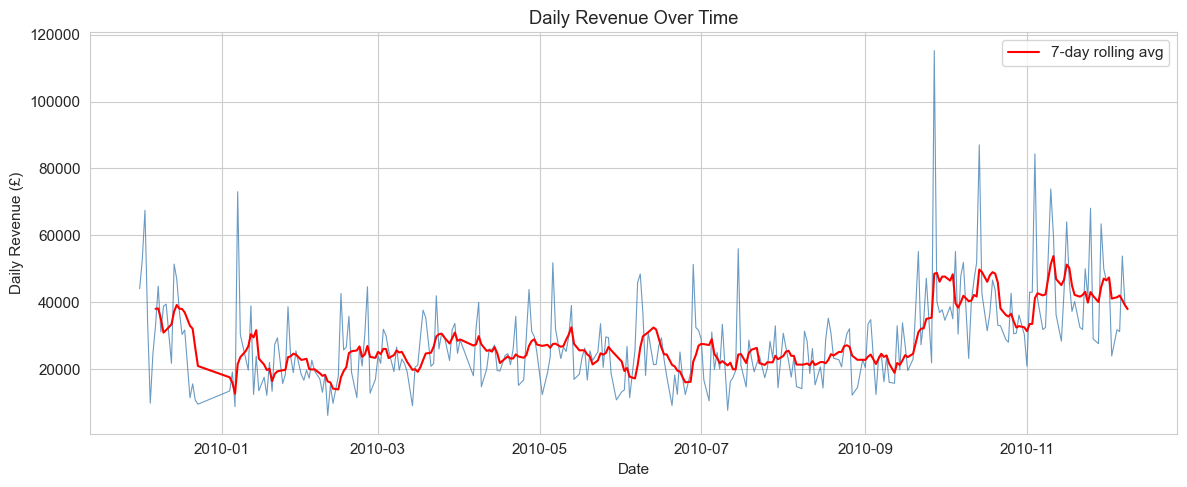

Date range: 2009-12-01 to 2010-12-09
Average daily revenue: £28,769
Peak day: 2010-09-27 (£115,243)


In [18]:
# EDA 1: Daily revenue over time
daily_rev = df_purchases.groupby(df_purchases['InvoiceDate'].dt.date)['Revenue'].sum()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(daily_rev.index, daily_rev.values, linewidth=0.8, alpha=0.8, color='steelblue')
ax.set_xlabel('Date')
ax.set_ylabel('Daily Revenue (£)')
ax.set_title('Daily Revenue Over Time')

# Add a 7-day rolling average
rolling = daily_rev.rolling(window=7).mean()
ax.plot(rolling.index, rolling.values, color='red', linewidth=1.5, label='7-day rolling avg')
ax.legend()
plt.tight_layout()
plt.show()
print(f"Date range: {daily_rev.index.min()} to {daily_rev.index.max()}")
print(f"Average daily revenue: £{daily_rev.mean():,.0f}")
print(f"Peak day: {daily_rev.idxmax()} (£{daily_rev.max():,.0f})")

**Pattern**: Revenues clearly show an upward trend over time since early 2010. It appears to have a marked increase during the fall-winter season (October to November) that may be attributed to holiday shopping. Additionally there is a lot of day to day volatility.

**Limitation**: We can only evaluate data for approximately twelve months; therefore we do not know if this is a recurring seasonal trend. Therefore it is possible that the spike is indicative of the company's increasing success rather than seasonal demand.

### EDA 2 - Invoice Value Distribution (Transactional Pattern)

**Question:** What is the distribution of invoice values (basket totals)? This explicitly reflects the transactional structure by aggregating at the invoice level.

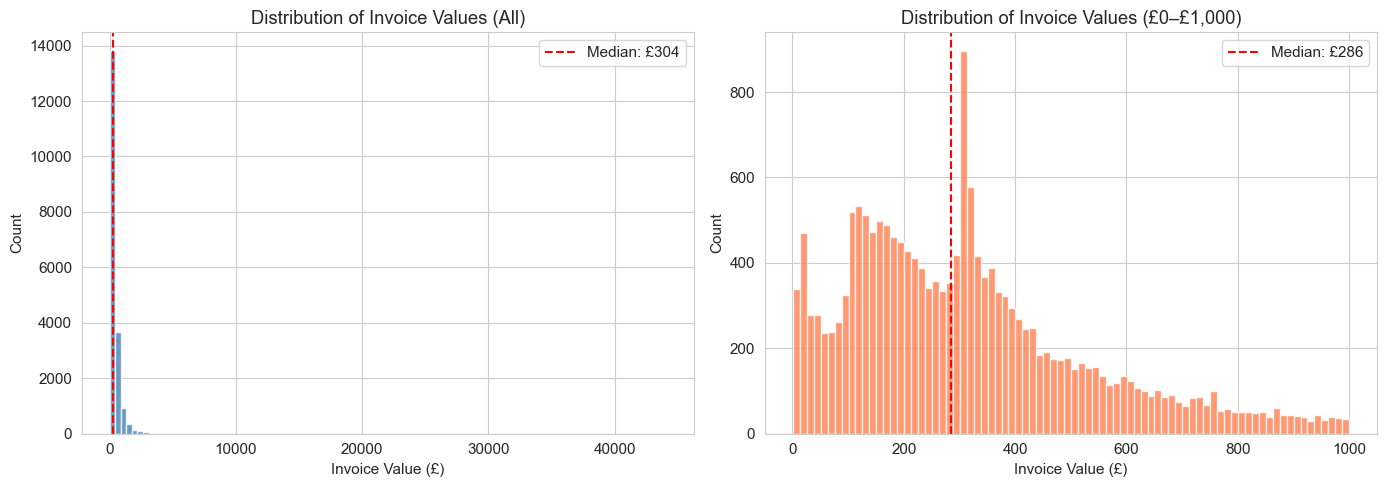

Number of invoices: 19,213
Mean invoice value:   £459.69
Median invoice value: £303.54
Max invoice value:    £44,051.60
Invoices > £1000:     1411 (7.3%)


In [19]:
# EDA 2: Invoice-level value distribution
invoice_value = df_purchases.groupby('Invoice')['Revenue'].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full distribution
axes[0].hist(invoice_value, bins=100, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Invoice Value (£)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Invoice Values (All)')
axes[0].axvline(invoice_value.median(), color='red', linestyle='--', label=f'Median: £{invoice_value.median():.0f}')
axes[0].legend()

# Zoomed in (< £1000) for clarity
zoomed = invoice_value[invoice_value.between(0, 1000)]
axes[1].hist(zoomed, bins=80, color='coral', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Invoice Value (£)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Invoice Values (£0–£1,000)')
axes[1].axvline(zoomed.median(), color='red', linestyle='--', label=f'Median: £{zoomed.median():.0f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Number of invoices: {len(invoice_value):,}")
print(f"Mean invoice value:   £{invoice_value.mean():.2f}")
print(f"Median invoice value: £{invoice_value.median():.2f}")
print(f"Max invoice value:    £{invoice_value.max():,.2f}")
print(f"Invoices > £1000:     {(invoice_value > 1000).sum()} ({(invoice_value > 1000).mean()*100:.1f}%)")

**Key pattern:** The distribution of invoice values in this dataset has a significant positive skewness - many invoices have low values (the median value is approximately £300). A "long-tail" exists on the right side of the histogram that includes many large order values.

Data that represents both B2B/wholesale and B2C retail typically displays the characteristics of this data set's invoice values.

**Limitation:** However, it should be noted that invoice values greater than £1,000 may represent a single bulk wholesale transaction and therefore could distort typical retail purchase values at the customer level. If not appropriately accounted for, these extreme values would also distort customer level revenue metrics.

### EDA 3 - Customer Purchase Frequency (Customer Pattern)

**Question:** How often do customers make purchases? Is this a mostly one-time or repeat customer base?

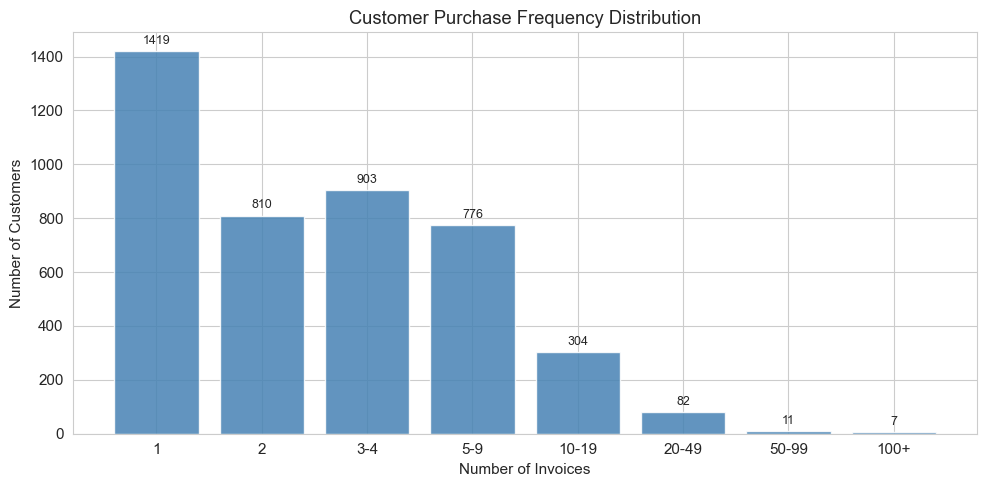

Total customers: 4,312
One-time buyers: 1419 (32.9%)
Repeat buyers (2+): 2893 (67.1%)
Frequent buyers (10+): 404 (9.4%)
Mean invoices per customer: 4.5
Median invoices per customer: 2


In [20]:
# EDA 3: Customer purchase frequency
cust_freq = df_purchases.groupby('Customer ID')['Invoice'].nunique()

fig, ax = plt.subplots(figsize=(10, 5))
freq_bins = [1, 2, 3, 5, 10, 20, 50, 100, cust_freq.max()+1]
freq_labels = ['1', '2', '3-4', '5-9', '10-19', '20-49', '50-99', '100+']
cust_freq_binned = pd.cut(cust_freq, bins=freq_bins, labels=freq_labels, right=False)
counts = cust_freq_binned.value_counts().sort_index()

bars = ax.bar(counts.index, counts.values, color='steelblue', edgecolor='white', alpha=0.85)
ax.set_xlabel('Number of Invoices')
ax.set_ylabel('Number of Customers')
ax.set_title('Customer Purchase Frequency Distribution')

# Add counts on bars
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 15,
            str(val), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print(f"Total customers: {len(cust_freq):,}")
print(f"One-time buyers: {(cust_freq == 1).sum()} ({(cust_freq == 1).mean()*100:.1f}%)")
print(f"Repeat buyers (2+): {(cust_freq >= 2).sum()} ({(cust_freq >= 2).mean()*100:.1f}%)")
print(f"Frequent buyers (10+): {(cust_freq >= 10).sum()} ({(cust_freq >= 10).mean()*100:.1f}%)")
print(f"Mean invoices per customer: {cust_freq.mean():.1f}")
print(f"Median invoices per customer: {cust_freq.median():.0f}")

**Primary Pattern**: There are many customers who are buying from you for the first time; however there are very few repeat customers that make up an extremely high percentage of your total sales. This creates a long-tail of customer purchasing frequency which makes it a great idea to predict when a customer will buy again.

**Limitation**: Your data window is approximately 12 months. If a customer is identified as a "one-time" buyer within this window, they may not yet be a repeat purchaser at this point in time because their next purchase has occurred after the end date of your data window. This represents a right-censored problem with all frequency based analyses.

### EDA 4 - Top 15 Products by Revenue (Product Pattern)

**Question:** Which products generate the most revenue? Is revenue concentrated in a few products or spread broadly?

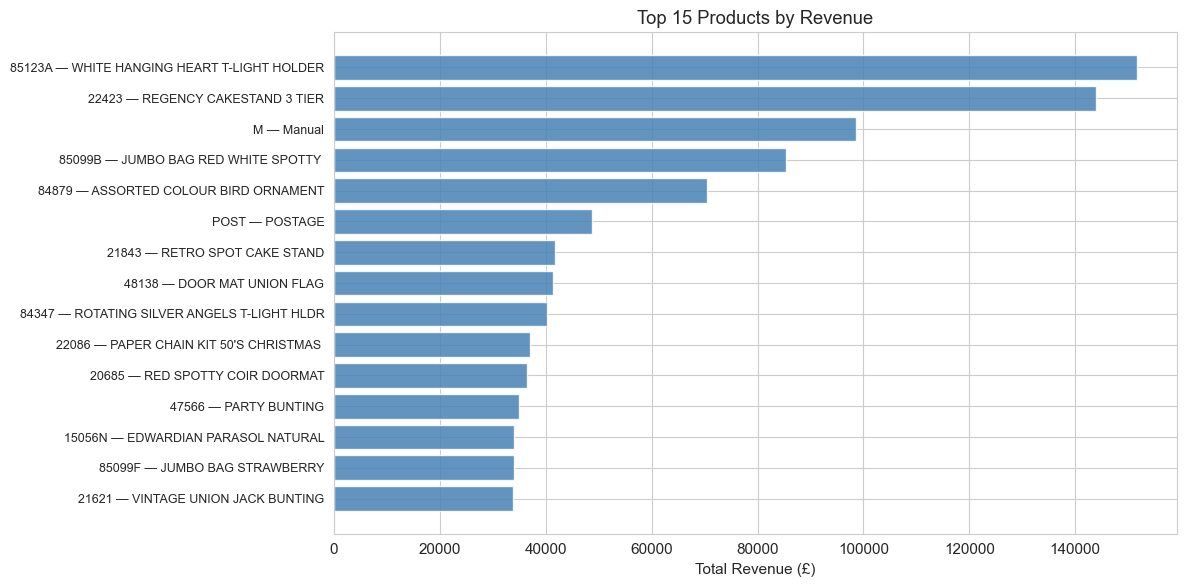

Top 5 products:
  1. 85123A (WHITE HANGING HEART T-LIGHT HOLDER): £151,624 across 3021 invoices
  2. 22423 (REGENCY CAKESTAND 3 TIER): £143,893 across 1687 invoices
  3. M (Manual): £98,561 across 382 invoices
  4. 85099B (JUMBO BAG RED WHITE SPOTTY ): £85,396 across 1708 invoices
  5. 84879 (ASSORTED COLOUR BIRD ORNAMENT): £70,494 across 1333 invoices

Top 10% of products account for 60.7% of total revenue


In [21]:
# EDA 4: Top products by revenue
product_rev = df_purchases.groupby('StockCode').agg(
    TotalRevenue=('Revenue', 'sum'),
    TotalQty=('Quantity', 'sum'),
    Description=('Description', 'first'),
    NumInvoices=('Invoice', 'nunique')
).sort_values('TotalRevenue', ascending=False)

top15 = product_rev.head(15)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(range(len(top15)), top15['TotalRevenue'], color='steelblue', alpha=0.85)
ax.set_yticks(range(len(top15)))
ax.set_yticklabels([f"{code} — {desc[:35]}" for code, desc in zip(top15.index, top15['Description'].fillna('N/A'))], fontsize=9)
ax.set_xlabel('Total Revenue (£)')
ax.set_title('Top 15 Products by Revenue')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 5 products:")
for i, (code, row) in enumerate(top15.head(5).iterrows()):
    print(f"  {i+1}. {code} ({row['Description'][:40]}): £{row['TotalRevenue']:,.0f} across {row['NumInvoices']} invoices")

# Concentration
top_10_pct = product_rev.head(int(len(product_rev)*0.1))['TotalRevenue'].sum() / product_rev['TotalRevenue'].sum() * 100
print(f"\nTop 10% of products account for {top_10_pct:.1f}% of total revenue")

**Key Pattern:** A very small number of products have the vast majority of all the revenue. Following a Pareto-type distribution, the top 10% of the products are responsible for approximately all of the total revenue. The majority of the top products appear to be postage or an adjustment (not a product) as opposed to actual product items.

**Limitations:** In addition to "StockCode" items that can include 'POST' or 'DOT', which represents postage charges or an adjustment (not a real product), these will inflate each individual product's level of revenue; therefore they should be considered with caution. While it may be somewhat of a limitation when modeling at the customer-product level because you would need to look at each individual product, for the customer level you can aggregate your data across multiple products.

### EDA 5 - Purchases by Hour of Day and Day of Week (Temporal + Transactional)

**Question:** When do customers place orders? Are there clear time-of-day and day-of-week patterns?

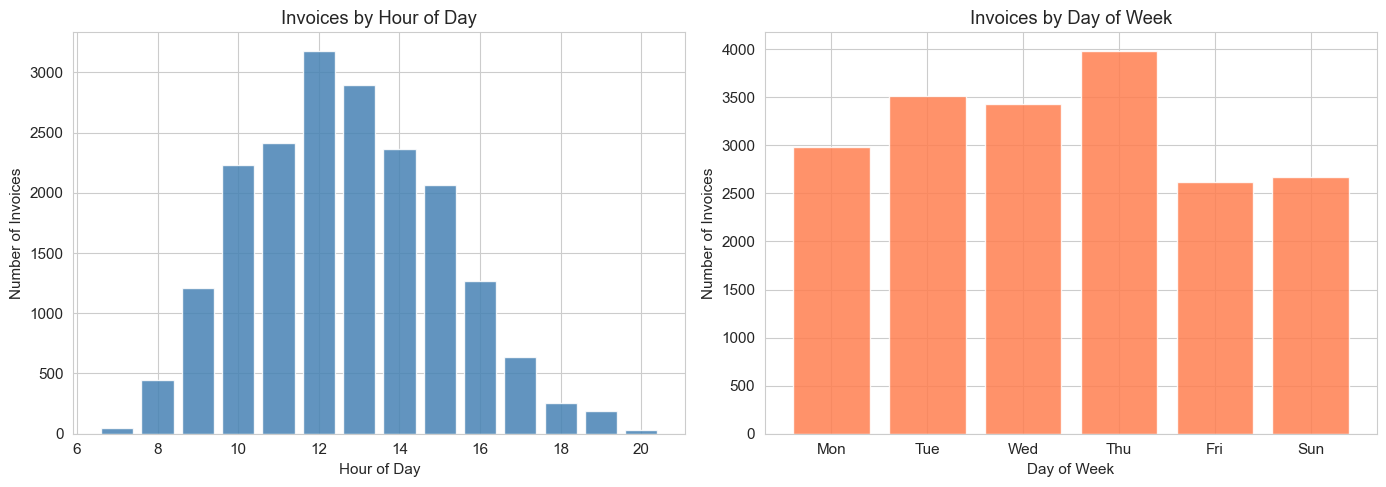

Peak hour: 12 (3173 invoices)
No Saturday data — likely closed on Saturdays


In [22]:
# EDA 5: Hourly and day-of-week patterns
df_purchases['Hour'] = df_purchases['InvoiceDate'].dt.hour
df_purchases['DayOfWeek'] = df_purchases['InvoiceDate'].dt.day_name()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hourly pattern (invoice count)
hourly = df_purchases.groupby('Hour')['Invoice'].nunique()
axes[0].bar(hourly.index, hourly.values, color='steelblue', alpha=0.85)
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Number of Invoices')
axes[0].set_title('Invoices by Hour of Day')

# Day of week pattern
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Sunday']
daily = df_purchases.groupby('DayOfWeek')['Invoice'].nunique().reindex(day_order)
axes[1].bar(range(len(daily)), daily.values, color='coral', alpha=0.85)
axes[1].set_xticks(range(len(daily)))
axes[1].set_xticklabels([d[:3] for d in day_order])
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Number of Invoices')
axes[1].set_title('Invoices by Day of Week')

plt.tight_layout()
plt.show()

print("Peak hour:", hourly.idxmax(), f"({hourly.max()} invoices)")
print("No Saturday data — likely closed on Saturdays")

**Key pattern:** Most of the orders occur in the middle of the day between 10am - 3pm. During these times, most of the orders seem to be entering at their peak around 12pm. The weekends show very little activity except for Sundays, which could indicate that this is a retail business that operates Monday through Friday; however, it also appears that there may be some online ordering taking place.

**Limitation:** This pattern reflects when invoices are processed, not when customers place orders. In order to determine whether orders were being entered as they came in or if they were being entered by hand in batches at specific times, it would be important to look into how orders are entered and processed. It could be possible that the hourly pattern is due to employee staffing, and not the way customers purchase products.

### EDA 6 - Revenue by Country (Excluding UK)

**Question:** Among non-UK countries, how is revenue distributed?

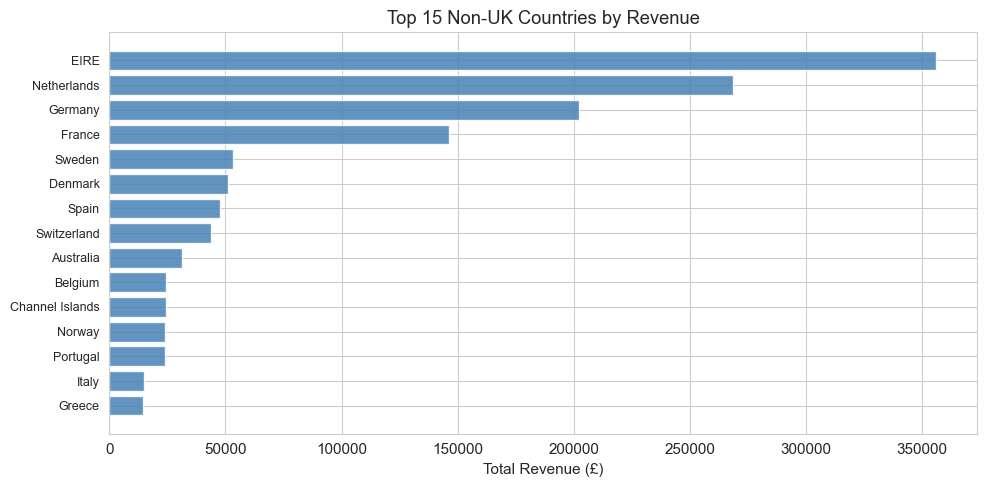

UK Revenue:     £7,414,756 (84.0%)
Non-UK Revenue: £1,417,247 (16.0%)


In [23]:
# EDA 6: Revenue by non-UK country
non_uk = df_purchases[df_purchases['Country'] != 'United Kingdom']
country_rev = non_uk.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(range(len(country_rev)), country_rev.values, color='steelblue', alpha=0.85)
ax.set_yticks(range(len(country_rev)))
ax.set_yticklabels(country_rev.index, fontsize=9)
ax.set_xlabel('Total Revenue (£)')
ax.set_title('Top 15 Non-UK Countries by Revenue')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# UK vs non-UK split
uk_rev = df_purchases[df_purchases['Country'] == 'United Kingdom']['Revenue'].sum()
non_uk_rev = non_uk['Revenue'].sum()
print(f"UK Revenue:     £{uk_rev:,.0f} ({uk_rev/(uk_rev+non_uk_rev)*100:.1f}%)")
print(f"Non-UK Revenue: £{non_uk_rev:,.0f} ({non_uk_rev/(uk_rev+non_uk_rev)*100:.1f}%)")

**Pattern Key:** Only three European nations (the U.K., the Netherlands, Eire/Ireland, and Germany) represent a large percentage of all non-U.K. revenues from this source. However, even the largest non-U.K. nation generates less than one percent of all the revenue generated by the U.K.

**Limitations:** The majority of the sample sizes in the other non-UK countries is relatively low; therefore, there can be little confidence about the validity or reliability of conclusions drawn at the national level for these other countries. The high UK concentration in the sample makes it likely that any model built with this sample will have learned UK customer behavior, rather than learning other behaviors.

## Task 6 - Reflection and Planning

### 3 Key Insights

1. All aspects of the data set are skewed toward the right the revenue data, the size of each basket purchased by the customer, and the number of times that the customer purchases in an observed time period all have very long tails with a few customers and a few products producing a majority of the revenue and/or number of times that a product is purchased. Therefore, any model developed from this data should be able to accurately model this right-skewness.

2. Customers who make purchases repeatedly versus those who do not make repeated purchases provide a natural division or segmentation of the customer base. Since many customers only make a single purchase during an observed time frame, there exists a large number of one-time customers; however, a smaller segment of customers consistently makes multiple purchases over an extended time frame. In addition, given that the goal of developing a model is to predict which customers will be repeat buyers, this provides a clear classification objective.

3. Data quality issues require careful treatment, not aggressive removal of relevant information. Approximately 20% of the data records lack a customer ID; approximately 2% of transactions were canceled. While these are both significant data quality problems, they can still be managed within a model framework if treated appropriately (i.e., remove the missing ID records; create a separate variable for canceled items). It would not be advisable to simply ignore these data quality issues.

### 2 Assumptions or Risks

1. **Right-Censorship**: When we see a 'one-time' customer they might just be an occasional purchaser who has been outside our observation period, so this will add noise to any of the binary targets for repeat purchasing behavior.

2. **Mixing Wholesale and Retail Orders** : The dataset most likely includes both B2B (wholesale) and B2C (retail) customers; however, it does not explicitly indicate which are which. If bulk orders occur in the data, they could skew customer level feature(s) unless addressed.

### Chosen Unit of Analysis

**Customer Level**, i.e., in each row there will be aggregated data of all transactions for each unique customer.

### Modelling Task for Next Week

I am going to create **Classification Model**, where I predict if a customer is a Repeat Buyer (> 1 invoice), or a One Time Buyer, utilising **Tree-Based Methods**; namely Decision Tree, Random Forest, Gradient Boosting. The target variable is directly aligned with the Unit of Analysis **Customer Level** which is also an easily interpretable Business Relevant Target.